In [2]:
# ═══════════════════════════════════════════════════════════════
# 1. Connect to Google Drive
# ═══════════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

import os, glob, re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from tqdm import tqdm
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import StratifiedShuffleSplit
import torchvision.transforms.functional as TF
import random
from torch.optim.lr_scheduler import CosineAnnealingLR
import cv2
from collections import Counter

Mounted at /content/drive


In [3]:
# ═══════════════════════════════════════════════════════════════
# 2. Path Settings
# ═══════════════════════════════════════════════════════════════

# Change this to match your data path in Google Drive
ROOT = "/content/drive/MyDrive/Project/Data"

# Path to save temporary files (in Colab)
OUTPUT_DIR = "/content"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✓ Libraries ready")
print("Data path:", ROOT)

# Check if the folder exists
if os.path.exists(ROOT):
    print("✓ Folder exists")
    items = os.listdir(ROOT)
    print(f"  Contents: {items}")
else:
    print("✗ Folder not found! Make sure:")
    print("  1. Google Drive is connected")
    print("  2. The path is correct")
    print("  3. Data exists in Drive")

✓ المكتبات جاهزة
مسار الداتا: /content/drive/MyDrive/Project/Data
✓ المجلد موجود
  المحتويات: ['Train', 'Val']


In [4]:
# ═══════════════════════════════════════════════════════════════
# 3. Load CSV files
# ═══════════════════════════════════════════════════════════════

def load_all_csvs(root):
    records = []

    # Search patterns based on data structure
    search_patterns = [
        os.path.join(root, "Train", "Gemini_Transcribed", "Csv", "*.csv"),
        os.path.join(root, "Train", "Manually_Verified", "Csv", "*.csv"),
        os.path.join(root, "Val", "Manually_Verified", "Csv", "*.csv"),
    ]

    for pattern in search_patterns:
        files = glob.glob(pattern)
        print(f"\n  Pattern: {pattern}")
        print(f"  → Found: {len(files)} files")

        # Extract split and subset from the path
        parts = pattern.replace(root, "").strip(os.sep).split(os.sep)
        split = parts[0] if len(parts) > 0 else "unknown"
        subset = parts[1] if len(parts) > 1 else "unknown"

        print(f"  → Split: {split}, Subset: {subset}")

        for fpath in files:
            fname = Path(fpath).stem
            try:
                df_csv = pd.read_csv(fpath)
                df_csv.columns = [c.strip().lower() for c in df_csv.columns]

                if "word" in df_csv.columns:
                    words = df_csv["word"].dropna().tolist()
                    sentence = " ".join(str(w).strip() for w in words if str(w).strip())

                    has_start = "start" in df_csv.columns and df_csv["start"].notna().any()
                    has_end = "end" in df_csv.columns and df_csv["end"].notna().any()

                    # Build video path
                    video_path = fpath.replace("/Csv/", "/Video/").replace(".csv", ".mp4")

                    records.append({
                        "file_id": fname,
                        "split": split,
                        "subset": subset,
                        "sentence": sentence,
                        "word_count": len(words),
                        "has_timestamps": has_start and has_end,
                        "csv_path": fpath,
                        "video_path": video_path,
                    })
            except Exception as e:
                print(f"    ⚠ Error in {fname}: {e}")

    return pd.DataFrame(records)

In [5]:
# ═══════════════════════════════════════════════════════════════
# 4. Load Data
# ═══════════════════════════════════════════════════════════════

df = load_all_csvs(ROOT)
print(f"\n{'='*60}")
print(f"✓ Total Videos: {len(df)}")

if len(df) > 0:
    print(f"  Train: {len(df[df.split=='Train'])}")
    print(f"  Val: {len(df[df.split=='Val'])}")
    print(f"\nSample:")
    print(df.head(5))
else:
    print("\n⚠ No data loaded!")


  Pattern: /content/drive/MyDrive/Project/Data/Train/Gemini_Transcribed/Csv/*.csv
  → Found: 11072 files
  → Split: Train, Subset: Gemini_Transcribed

  Pattern: /content/drive/MyDrive/Project/Data/Train/Manually_Verified/Csv/*.csv
  → Found: 1759 files
  → Split: Train, Subset: Manually_Verified

  Pattern: /content/drive/MyDrive/Project/Data/Val/Manually_Verified/Csv/*.csv
  → Found: 250 files
  → Split: Val, Subset: Manually_Verified

✓ إجمالي الفيديوهات: 13081
  Train: 12831
  Val: 250

عينة:
  file_id  split              subset                         sentence  \
0   17895  Train  Gemini_Transcribed  قَالَتْ مَصَادِرُ عَسْكَرِيَّةٌ   
1   17917  Train  Gemini_Transcribed    قَالَتْ مَصَادِرُ لِلْجَزِيرْ   
2   17901  Train  Gemini_Transcribed          مَصَادِرُ عَسْكَرِيَّةٌ   
3   17886  Train  Gemini_Transcribed    قَالَتْ مَصَادِرُ أَمْنِيَّةٌ   
4   17911  Train  Gemini_Transcribed    قَالَتْ مَصَادِرُ لِلْجَزِيرْ   

   word_count  has_timestamps  \
0           3           F

In [6]:
# ═══════════════════════════════════════════════════════════════
# 5. Sentence Analysis
# ═══════════════════════════════════════════════════════════════

sentence_counts = df["sentence"].value_counts()

print(f"\n{'='*60}")
print(f"📊 Total Videos: {len(df)}")
print(f"📝 Unique Sentences: {sentence_counts.nunique()}")
print(f"⏱ Videos with Timestamps: {df.has_timestamps.sum()}")
print(f"⏱ Videos without Timestamps: {(~df.has_timestamps).sum()}")
print(f"{'='*60}")

print("\n🔝 Top 20 Most Frequent Sentences:")
print(sentence_counts.head(20).to_string())


📊 إجمالي الفيديوهات: 13081
📝 جمل مختلفة (unique): 35
⏱ فيديوهات بـ timestamps: 0
⏱ فيديوهات بدون timestamps: 13081

🔝 أكثر 20 جملة تكرارًا:
sentence
ٱسَّلَامُ عَلَيْكُمْ                      111
أَهْلً بِكُمْ إِلَى مُوجَزِ                74
مُوجَزُ ٱلْأَنۢبَاءِ مِنْ قَنَاةِ          68
أَفَادَ مُرَاسِلُ ٱلْجَزِيرَةِ             68
إِلَى ٱلِّقَاءِ                            54
قَالَ مُرَاسِلُ ٱلْجَزِيرَةِ               48
نِهَايَةُ ٱلْمُوجَزِ إِلَى ٱلِّقَاءِ       40
مِيلِيشِيَا ٱلْحُوثِيِّ وَقُوَّاتِ         34
قَالَتْ مَصَادِرُ                          33
مِنْ جِهَتِهِ قَالَ                        32
ٱلْأَمْرِيكِيِّ دُونَالْدْ تْرَامْبْ       30
قَالَ وَزِيرُ ٱلْخَارِجِيَّةِ              29
ٱدَّوْلَةُ ٱلْإِسْلَامِيَّةُ               29
ٱسَّلَامُ عَلَيْكُمْ وَرَحْمَةُ ٱلَّهِ     27
ٱلْحُوثِيِّ وَقُوَّاتِ ٱرَّئِيسِ           26
قَالَ ٱلْمُتَحَدِّثُ بِٱسْمِ               26
قَالَ ٱلْمُتَحَدِّثُ بِاسْمِ               25
وَٱسَّلَامُ عَلَيْكُمْ                     24
جَزُ إِلَى ٱلِّقَاءِ  

In [7]:
# ═══════════════════════════════════════════════════════════════
# 6. Select Classes
# ═══════════════════════════════════════════════════════════════

MIN_SAMPLES = 5

top_sentences = sentence_counts[sentence_counts >= MIN_SAMPLES]
print(f"\n✓ Eligible sentences as classes (frequency ≥ {MIN_SAMPLES}): {len(top_sentences)}")

df_filtered = df[df["sentence"].isin(top_sentences.index)].copy()
df_filtered["label"] = pd.Categorical(df_filtered["sentence"]).codes

print(f"\n📦 Dataset after filtering: {len(df_filtered)} videos")
print(f"🏷 Number of classes: {df_filtered['label'].nunique()}")
print("\nSample distribution per class:")
print(df_filtered.groupby("sentence")["file_id"].count().sort_values(ascending=False))


✓ جمل مؤهلة كـ classes (تكرار ≥ 5): 227

📦 Dataset بعد الفلترة: 2410 فيديو
🏷 عدد الـ classes: 227

توزيع العينات لكل class:
sentence
ٱسَّلَامُ عَلَيْكُمْ                            111
أَهْلً بِكُمْ إِلَى مُوجَزِ                      74
أَفَادَ مُرَاسِلُ ٱلْجَزِيرَةِ                   68
مُوجَزُ ٱلْأَنۢبَاءِ مِنْ قَنَاةِ                68
إِلَى ٱلِّقَاءِ                                  54
                                               ... 
ٱلْمُحَدِّثَةُ بِاسْمِ ٱلْخَارِجِيَّةِ            5
ٱلْمُقَاوَمَةِ ٱشَّعْبِيَّةِ                      5
ٱلْمُقَاوَمَةُ ٱشَّعْبِ                           5
ٱلْوُزَرَاءِ ٱلْإِسْرَائِيلِيِّ بِنْيَامِينْ      5
ٱنْتَهَى ٱلْمُوجَزُ إِلَى ٱلِّقَاءِ               5
Name: file_id, Length: 227, dtype: int64


In [9]:
# ═══════════════════════════════════════════════════════════════
# 7. Verify Video Existence
# ═══════════════════════════════════════════════════════════════

df_filtered["video_exists"] = df_filtered["video_path"].apply(os.path.exists)

print(f"\n✓ Videos found: {df_filtered.video_exists.sum()}")
print(f"✗ Missing videos: {(~df_filtered.video_exists).sum()}")

# If no videos were found, try other extensions
if df_filtered.video_exists.sum() == 0 and len(df_filtered) > 0:
    print("\n⚠ No videos found — trying other extensions...")
    for ext in [".avi", ".mpg", ".mpeg", ".mkv", ".mov", ".webm"]:
        test_path = df_filtered.iloc[0]["video_path"].replace(".mp4", ext)
        if os.path.exists(test_path):
            print(f"✓ Correct extension is: {ext}")
            df_filtered["video_path"] = df_filtered["video_path"].str.replace(".mp4", ext)
            break

df_filtered.to_csv(os.path.join(OUTPUT_DIR, "dataset_index.csv"), index=False)
print("\n✓ dataset_index.csv saved")

print(f"\nFinal summary:")
print(f"  Number of videos: {len(df_filtered)}")
print(f"  Number of classes: {df_filtered.label.nunique()}")
print(f"  Train: {len(df_filtered[df_filtered.split=='Train'])}")
print(f"  Val: {len(df_filtered[df_filtered.split=='Val'])}")


✓ فيديوهات موجودة: 2408
✗ فيديوهات مفقودة: 2

✓ dataset_index.csv محفوظ

ملخص نهائي:
  عدد الفيديوهات: 2410
  عدد الـ classes: 227
  Train: 2390
  Val: 20


In [10]:
# ═══════════════════════════════════════════════════════════════
# 8. Select Top-N Classes
# ═══════════════════════════════════════════════════════════════

N_CLASSES = 10

df = pd.read_csv(os.path.join(OUTPUT_DIR, "dataset_index.csv"))

top_n = df["sentence"].value_counts().head(N_CLASSES)
print(f"\n✓ Selected {N_CLASSES} classes:\n")
for i, (sent, count) in enumerate(top_n.items()):
    print(f"  {i:>2}. [{count:>3} samples] {sent}")

df_top = df[df["sentence"].isin(top_n.index)].copy()

label_map = {sent: i for i, sent in enumerate(top_n.index)}
df_top["label"] = df_top["sentence"].map(label_map)

df_top = df_top[df_top["video_path"].apply(os.path.exists)].copy()
df_top = df_top.reset_index(drop=True)

print(f"\n📦 Total videos used: {len(df_top)}")
print(f"🏷 Number of classes: {df_top['label'].nunique()}")
print(f"📈 Average samples / class: {len(df_top)/N_CLASSES:.1f}")
print(f"  Train: {len(df_top[df_top.split=='Train'])}")
print(f"  Val: {len(df_top[df_top.split=='Val'])}")

df_top.to_csv(os.path.join(OUTPUT_DIR, "dataset_top.csv"), index=False)
print("\n✓ dataset_top.csv saved")


✓ الـ 10 classes المختارة:

   0. [111 عينة] ٱسَّلَامُ عَلَيْكُمْ
   1. [ 74 عينة] أَهْلً بِكُمْ إِلَى مُوجَزِ
   2. [ 68 عينة] أَفَادَ مُرَاسِلُ ٱلْجَزِيرَةِ
   3. [ 68 عينة] مُوجَزُ ٱلْأَنۢبَاءِ مِنْ قَنَاةِ
   4. [ 54 عينة] إِلَى ٱلِّقَاءِ
   5. [ 48 عينة] قَالَ مُرَاسِلُ ٱلْجَزِيرَةِ
   6. [ 40 عينة] نِهَايَةُ ٱلْمُوجَزِ إِلَى ٱلِّقَاءِ
   7. [ 34 عينة] مِيلِيشِيَا ٱلْحُوثِيِّ وَقُوَّاتِ
   8. [ 33 عينة] قَالَتْ مَصَادِرُ
   9. [ 32 عينة] مِنْ جِهَتِهِ قَالَ

📦 إجمالي الفيديوهات المستخدمة: 561
🏷 عدد الـ classes: 10
📈 متوسط عينات / class: 56.1
  Train: 553
  Val: 8

✓ dataset_top.csv محفوظ


In [11]:
# ═══════════════════════════════════════════════════════════════
# 9. Extract Lip Region with OpenCV (No MediaPipe!)
# ═══════════════════════════════════════════════════════════════

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def extract_lip_region_cv2(frame_bgr, out_h=64, out_w=64):
    """
    Detects face → crops lower third (mouth region)
    Fallback: lower center of image if no face is detected
    """
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=3,
        minSize=(60, 60)
    )

    if len(faces) > 0:
        # Largest face
        x, y, fw, fh = max(faces, key=lambda f: f[2] * f[3])

        # Lower third of face = mouth region
        mouth_y1 = y + int(fh * 0.60)
        mouth_y2 = y + int(fh * 0.95)
        mouth_x1 = x + int(fw * 0.10)
        mouth_x2 = x + int(fw * 0.90)

        # Ensure boundaries
        mouth_y1 = max(0, mouth_y1)
        mouth_y2 = min(h, mouth_y2)
        mouth_x1 = max(0, mouth_x1)
        mouth_x2 = min(w, mouth_x2)

        crop = gray[mouth_y1:mouth_y2, mouth_x1:mouth_x2]
        if crop.size > 0:
            return cv2.resize(crop, (out_w, out_h)), True

    # Fallback: lower center quarter
    y1 = int(h * 0.55)
    y2 = int(h * 0.85)
    x1 = int(w * 0.20)
    x2 = int(w * 0.80)
    crop = gray[y1:y2, x1:x2]
    if crop.size > 0:
        return cv2.resize(crop, (out_w, out_h)), False
    return np.zeros((out_h, out_w), dtype=np.uint8), False

def video_to_lip_strip(video_path, n_frames=15, out_h=64, out_w=64):
    """
    Video → Spatial Strip from lip region
    """
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total == 0:
        cap.release()
        return None, 0

    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames = []
    face_found = 0

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()

        if not ret:
            frames.append(np.zeros((out_h, out_w), dtype=np.uint8))
            continue

        lip, found = extract_lip_region_cv2(frame, out_h, out_w)
        frames.append(lip)
        if found:
            face_found += 1

    cap.release()
    return np.concatenate(frames, axis=1), face_found  # (64, 960)

print("✓ Lip extraction functions ready — OpenCV (No MediaPipe)")

✓ دوال استخراج الشفاه جاهزة — OpenCV (بدون MediaPipe)


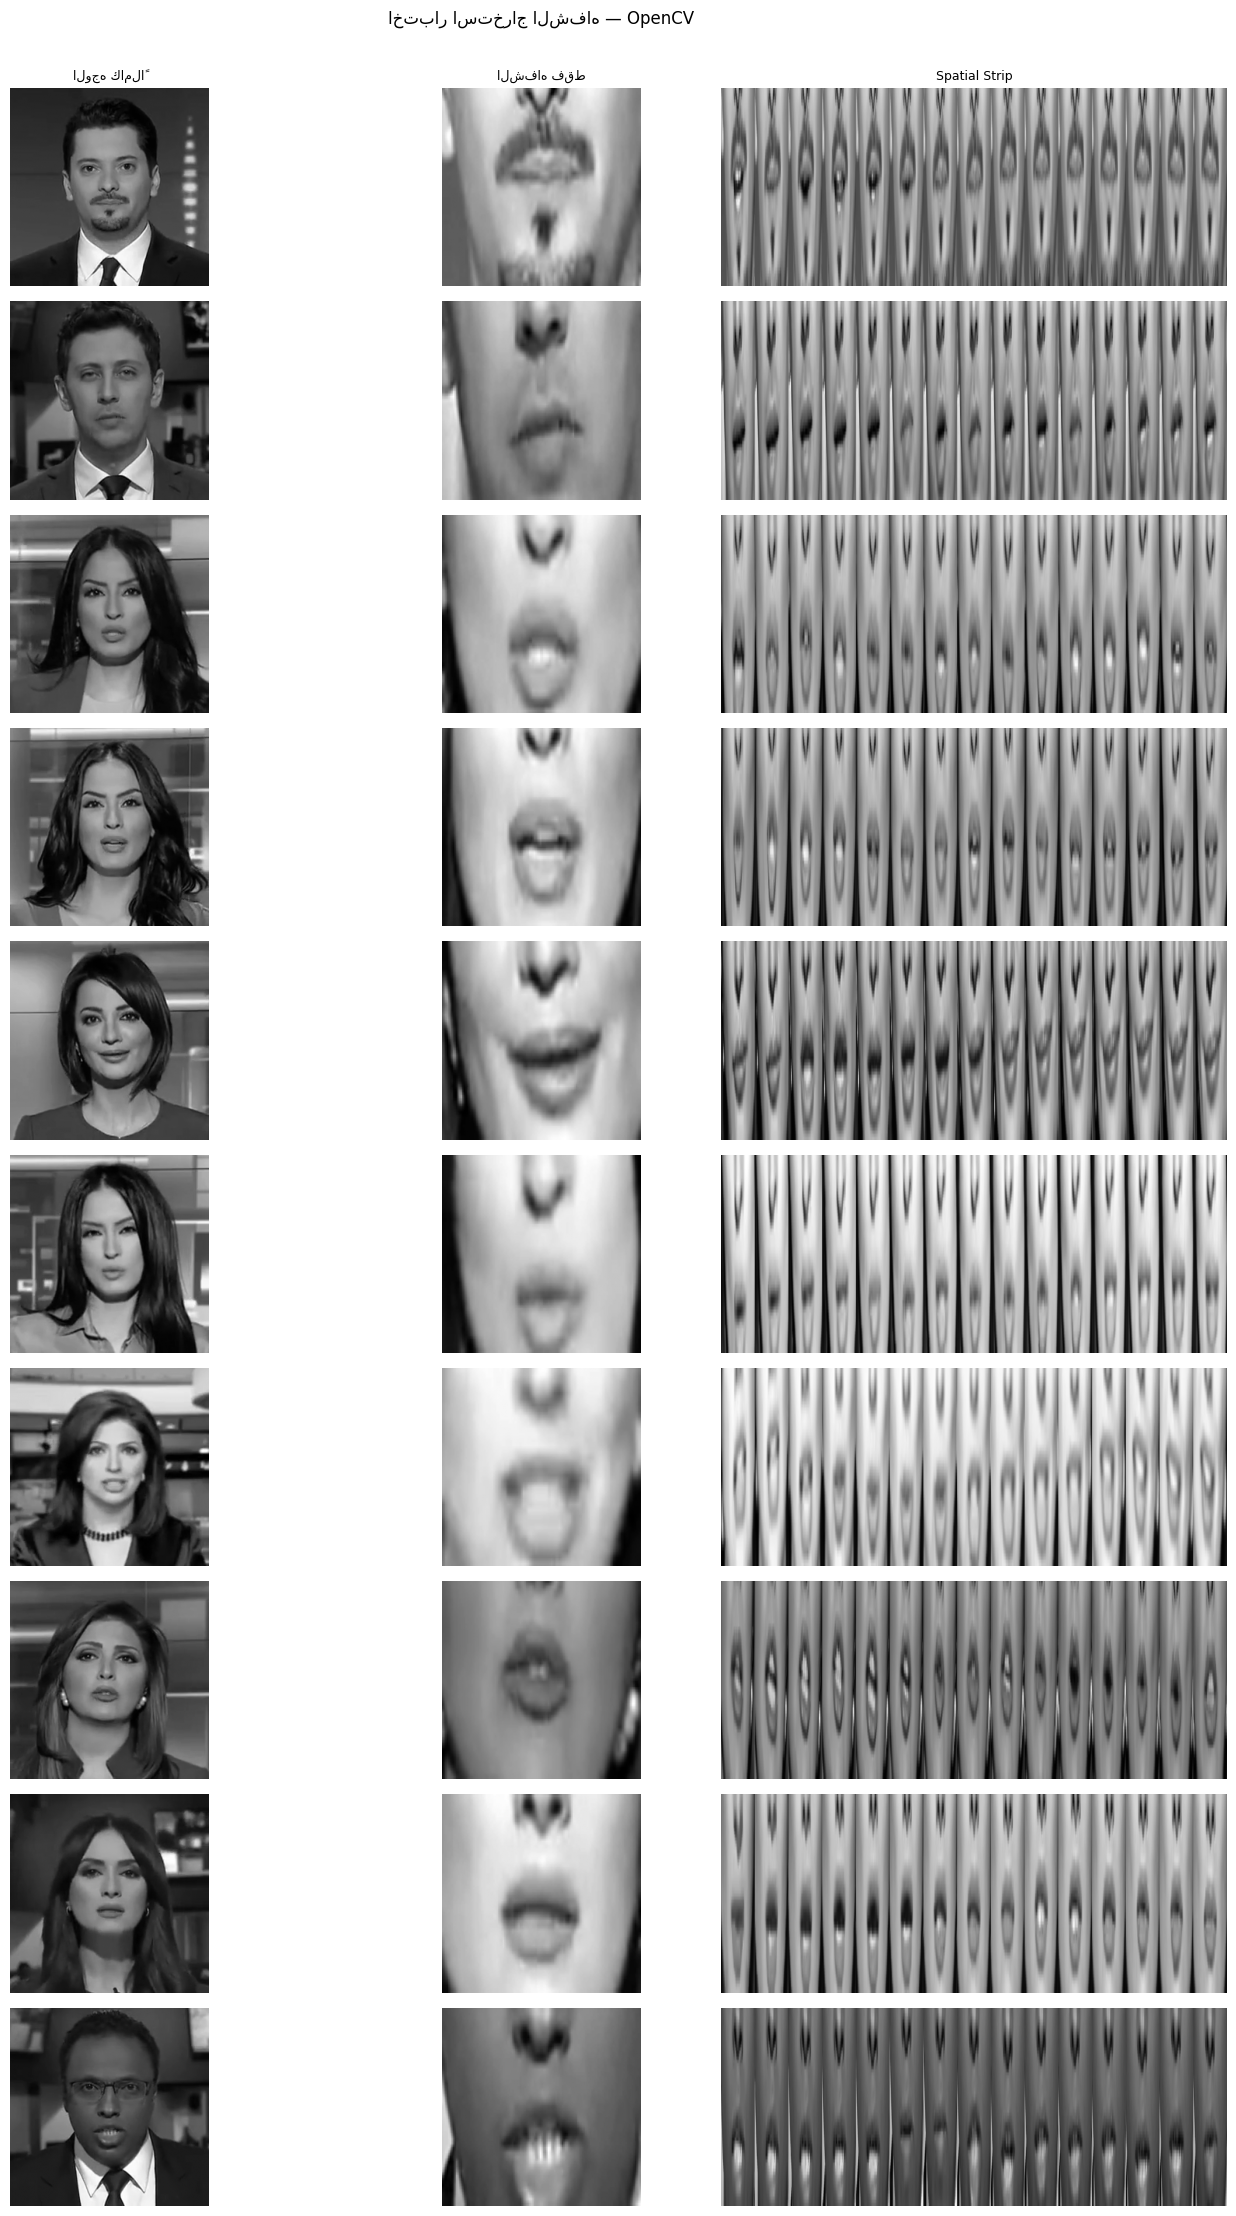

In [12]:
# ═══════════════════════════════════════════════════════════════
# 10. Test Lip Extraction on Samples
# ═══════════════════════════════════════════════════════════════

df_top = pd.read_csv(os.path.join(OUTPUT_DIR, "dataset_top.csv"))

if len(df_top) > 0:
    fig, axes = plt.subplots(min(N_CLASSES, len(df_top["label"].unique())), 3, figsize=(14, 22))
    if N_CLASSES == 1:
        axes = [axes]

    unique_labels = sorted(df_top["label"].unique())

    for idx, cls in enumerate(unique_labels[:N_CLASSES]):
        rows = df_top[df_top["label"] == cls]
        if len(rows) == 0:
            continue
        sample_path = rows.iloc[0]["video_path"]

        cap = cv2.VideoCapture(sample_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.set(cv2.CAP_PROP_POS_FRAMES, total // 2)
        ret, frame = cap.read()
        cap.release()

        if not ret:
            continue

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        lip, found = extract_lip_region_cv2(frame, 128, 128)

        # Column 1: Full Face Frame
        axes[idx][0].imshow(gray, cmap="gray")
        axes[idx][0].set_ylabel(f"[{cls}]", fontsize=8, rotation=0, labelpad=22)
        if idx == 0: axes[idx][0].set_title("Full Face", fontsize=9)
        axes[idx][0].axis("off")

        # Column 2: Lip Region
        axes[idx][1].imshow(lip, cmap="gray")
        status = "✓ face" if found else "↩ fallback"
        if idx == 0: axes[idx][1].set_title("Lip Region Only", fontsize=9)
        axes[idx][1].set_xlabel(status, fontsize=7)
        axes[idx][1].axis("off")

        # Column 3: The Strip
        strip, n_found = video_to_lip_strip(sample_path)
        if strip is not None:
            axes[idx][2].imshow(strip, cmap="gray", aspect="auto")
            if idx == 0: axes[idx][2].set_title("Spatial Strip", fontsize=9)
            axes[idx][2].set_xlabel(f"face in {n_found}/15 frames", fontsize=7)
        axes[idx][2].axis("off")

    plt.suptitle("Lip Extraction Test — OpenCV", fontsize=12, y=1.005)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "lip_test_opencv.png"), dpi=100, bbox_inches="tight")
    plt.show()

In [13]:
# ═══════════════════════════════════════════════════════════════
# 11. Convert all videos to Strips
# ═══════════════════════════════════════════════════════════════

N_FRAMES = 15
FRAME_H = 64
FRAME_W = 64

X, y = [], []
failed = 0

print("\n⏳ Converting videos to Strips...")

for _, row in tqdm(df_top.iterrows(), total=len(df_top)):
    strip, _ = video_to_lip_strip(row["video_path"], n_frames=N_FRAMES, out_h=FRAME_H, out_w=FRAME_W)
    if strip is not None:
        X.append(strip)
        y.append(int(row["label"]))
    else:
        failed += 1

if len(X) > 0:
    X = np.array(X, dtype=np.float32) / 255.0  # normalize [0, 1]
    y = np.array(y, dtype=np.int64)
    X = X[:, np.newaxis, :, :]  # (N, 1, H, W)

    print(f"\n✓ X shape: {X.shape}   → (samples, channels, height, width)")
    print(f"✓ y shape: {y.shape}")
    print(f"✗ Failed videos: {failed}")
    print(f"\nDataset size in memory: {X.nbytes / 1e6:.1f} MB")

    label_names = {v: k for k, v in label_map.items()}

    with open(os.path.join(OUTPUT_DIR, "lip_data.pkl"), "wb") as f:
        pickle.dump({
            "X": X,
            "y": y,
            "label_map": label_map,
            "label_names": label_names,
            "df": df_top,
        }, f)

    print("✓ lip_data.pkl saved — ready for training!")
else:
    print("⚠ No valid videos to process!")


⏳ جاري تحويل الفيديوهات إلى Strips...


100%|██████████| 561/561 [11:35<00:00,  1.24s/it]



✓ X shape: (561, 1, 64, 960)   → (samples, channels, height, width)
✓ y shape: (561,)
✗ فيديوهات فاشلة: 0

حجم الـ Dataset في الذاكرة: 137.9 MB
✓ lip_data.pkl محفوظ — جاهز للتدريب!


In [14]:
# ═══════════════════════════════════════════════════════════════
# 12. Load Data and Prepare DataLoaders
# ═══════════════════════════════════════════════════════════════

with open(os.path.join(OUTPUT_DIR, "lip_data.pkl"), "rb") as f:
    data = pickle.load(f)

X = data["X"]
y = data["y"]
label_names = data["label_names"]

print(f"\nX: {X.shape} | y: {y.shape}")
print(f"Classes: {len(label_names)}")

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(sss.split(X, y))

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

print(f"\nTrain: {len(X_train)} | Val: {len(X_val)}")
print("Train distribution:", {label_names[i]: int((y_train == i).sum()) for i in range(N_CLASSES)})

class LipDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        x = self.X[i]  # (1, 64, 960)

        if self.augment:
            # 1) Random horizontal flip
            if random.random() < 0.5:
                x = TF.hflip(x)

            # 2) Random brightness/contrast
            factor = random.uniform(0.8, 1.2)
            x = torch.clamp(x * factor, 0, 1)

            # 3) Light random noise
            if random.random() < 0.3:
                x = x + torch.randn_like(x) * 0.02
                x = torch.clamp(x, 0, 1)

        return x, self.y[i]

# Weighted Sampler to handle class imbalance
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
sample_weights = class_weights[y_train]
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float32),
    num_samples=len(y_train),
    replacement=True
)

train_ds = LipDataset(X_train, y_train, augment=True)
val_ds = LipDataset(X_val, y_val, augment=False)

train_dl = DataLoader(train_ds, batch_size=16, sampler=sampler, num_workers=2, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f"✓ Train batches: {len(train_dl)} | Val batches: {len(val_dl)}")


X: (561, 1, 64, 960) | y: (561,)
Classes: 10

Train: 448 | Val: 113
توزيع Train: {'ٱسَّلَامُ عَلَيْكُمْ': 88, 'أَهْلً بِكُمْ إِلَى مُوجَزِ': 59, 'أَفَادَ مُرَاسِلُ ٱلْجَزِيرَةِ': 54, 'مُوجَزُ ٱلْأَنۢبَاءِ مِنْ قَنَاةِ': 54, 'إِلَى ٱلِّقَاءِ': 43, 'قَالَ مُرَاسِلُ ٱلْجَزِيرَةِ': 38, 'نِهَايَةُ ٱلْمُوجَزِ إِلَى ٱلِّقَاءِ': 32, 'مِيلِيشِيَا ٱلْحُوثِيِّ وَقُوَّاتِ': 27, 'قَالَتْ مَصَادِرُ': 27, 'مِنْ جِهَتِهِ قَالَ': 26}
✓ Train batches: 28 | Val batches: 8


In [14]:
# ═══════════════════════════════════════════════════════════════
# 13. Define the Model
# ═══════════════════════════════════════════════════════════════

class LipReadingCNN(nn.Module):
    """
    CNN that processes a Spatial Strip (1 × 64 × 960).
    Filters are wide horizontally (axis=1 in the Strip = time)
    to capture temporal changes in the lips.
    """
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1 — Basic lip edges
            # kernel (3,7): 3 vertical, 7 horizontal → sees motion across two consecutive frames
            nn.Conv2d(1, 32, kernel_size=(3, 7), padding=(1, 3)),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 4)),  # → (32, 32, 240)

            # Block 2 — Lip motion patterns
            nn.Conv2d(32, 64, kernel_size=(3, 5), padding=(1, 2)),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 4)),  # → (64, 16, 60)

            # Block 3 — Spatio-temporal representations
            nn.Conv2d(64, 128, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2)),  # → (128, 8, 30)

            # Block 4 — High-level abstraction
            nn.Conv2d(128, 256, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 8)),  # → (256, 4, 8) = 8192
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(256 * 4 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.6),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\n✓ Device: {device}")

model = LipReadingCNN(num_classes=N_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Parameters: {total_params:,}")

dummy = torch.randn(2, 1, 64, 960).to(device)
out = model(dummy)
print(f"✓ Output shape: {out.shape}  → (batch=2, classes={N_CLASSES})")


✓ Device: cpu
✓ Parameters: 4,663,242
✓ Output shape: torch.Size([2, 10])  → (batch=2, classes=10)


In [18]:
# ═══════════════════════════════════════════════════════════════
# 14. Define the Optimized Model (replace entire old section)
# ═══════════════════════════════════════════════════════════════

class LipReadingCNN(nn.Module):  # Same name — no need to change elsewhere in the code
    def __init__(self, num_classes=10, dropout=0.6):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1 — fewer filters + Dropout2d
            nn.Conv2d(1, 16, kernel_size=(3, 7), padding=(1, 3)),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 4)),
            nn.Dropout2d(0.1),

            # Block 2
            nn.Conv2d(16, 32, kernel_size=(3, 5), padding=(1, 2)),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 4)),
            nn.Dropout2d(0.15),

            # Block 3
            nn.Conv2d(32, 64, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2)),
            nn.Dropout2d(0.2),

            # Block 4
            nn.Conv2d(64, 128, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 8)),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(128 * 4 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.8),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✓ Device: {device}")

model = LipReadingCNN(num_classes=N_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Parameters: {total_params:,}")

dummy = torch.randn(2, 1, 64, 960).to(device)
out = model(dummy)
print(f"✓ Output shape: {out.shape}")

✓ Device: cpu
✓ Parameters: 1,152,298
✓ Output shape: torch.Size([2, 10])


In [15]:
# ═══════════════════════════════════════════════════════════════
# 15. Training
# ═══════════════════════════════════════════════════════════════

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=40, eta_min=1e-6)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

EPOCHS = 40

def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            if train:
                optimizer.zero_grad()
            out = model(X_b)
            loss = criterion(out, y_b)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * len(y_b)
            correct += (out.argmax(1) == y_b).sum().item()
            total += len(y_b)

    return total_loss / total, correct / total

history = {"tr_loss": [], "val_loss": [], "tr_acc": [], "val_acc": []}
best_val_acc = 0.0

print(f"\n{'Epoch':>5} | {'Tr Loss':>8} | {'Tr Acc':>7} | {'Val Loss':>9} | {'Val Acc':>8} | {'LR':>8}")
print("-" * 60)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_dl, optimizer, criterion, device, train=True)
    val_loss, val_acc = run_epoch(model, val_dl, optimizer, criterion, device, train=False)
    scheduler.step()

    history["tr_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["tr_acc"].append(tr_acc)
    history["val_acc"].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "lip_cnn_best.pth"))
        mark = " ✓ best"
    else:
        mark = ""

    if epoch % 5 == 0 or epoch == 1:
        lr = scheduler.get_last_lr()[0]
        print(f"{epoch:>5} | {tr_loss:>8.4f} | {tr_acc:>6.1%} | {val_loss:>9.4f} | {val_acc:>7.1%} | {lr:>8.2e}{mark}")

print(f"\n✓ Best Val Accuracy: {best_val_acc:.1%}")


Epoch |  Tr Loss |  Tr Acc |  Val Loss |  Val Acc |       LR
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


    1 |   2.3440 |  11.2% |    2.2959 |    6.2% | 3.00e-04 ✓ best
    5 |   2.0021 |  29.9% |    1.9181 |   39.8% | 2.89e-04 ✓ best
   10 |   1.4054 |  59.4% |    1.6271 |   54.0% | 2.56e-04 ✓ best
   15 |   1.0503 |  80.6% |    1.5016 |   55.8% | 2.08e-04
   20 |   0.8579 |  89.3% |    1.2849 |   69.9% | 1.50e-04 ✓ best
   25 |   0.7209 |  95.5% |    1.1939 |   69.9% | 9.33e-05
   30 |   0.6748 |  98.0% |    1.1570 |   75.2% | 4.48e-05 ✓ best
   35 |   0.6383 |  99.3% |    1.1563 |   75.2% | 1.24e-05
   40 |   0.6408 |  98.7% |    1.1579 |   75.2% | 1.00e-06

✓ أفضل Val Accuracy: 76.1%


In [21]:
# ═══════════════════════════════════════════════════════════════
# 16. Original Model (Achieved 76.1%) — Reverting to it
# ═══════════════════════════════════════════════════════════════

class LipReadingCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(3, 7), padding=(1, 3)),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 4)),

            nn.Conv2d(32, 64, kernel_size=(3, 5), padding=(1, 2)),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 4)),

            nn.Conv2d(64, 128, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2)),

            nn.Conv2d(128, 256, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 8)),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(256 * 4 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.6),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✓ Device: {device}")

model = LipReadingCNN(num_classes=N_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Parameters: {total_params:,}")

dummy = torch.randn(2, 1, 64, 960).to(device)
out = model(dummy)
print(f"✓ Output shape: {out.shape}")

# ═══════════════════════════════════════════════════════════════
# 13. Stronger Data Augmentation — This is the only required modification
# ═══════════════════════════════════════════════════════════════

class LipDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        x = self.X[i]

        if self.augment:
            # 1) Random horizontal flip
            if random.random() < 0.5:
                x = TF.hflip(x)

            # 2) Random brightness/contrast (wider range)
            factor = random.uniform(0.6, 1.4)
            x = torch.clamp(x * factor, 0, 1)

            # 3) Stronger random noise
            if random.random() < 0.5:
                x = x + torch.randn_like(x) * 0.04
                x = torch.clamp(x, 0, 1)

            # 4) Random erasing (erase a random part of the strip)
            if random.random() < 0.3:
                h, w = x.shape[1], x.shape[2]
                eh, ew = h // 3, w // 10  # Erase 33% of height and 10% of width
                ey = random.randint(0, h - eh)
                ex = random.randint(0, w - ew)
                x[:, ey:ey+eh, ex:ex+ew] = 0

            # 5) Very slight random rotation (for lips)
            if random.random() < 0.3:
                angle = random.uniform(-2, 2)
                x = TF.rotate(x, angle)

            # 6) Random crop and resize (zoom in/out)
            if random.random() < 0.3:
                scale = random.uniform(0.9, 1.1)
                new_h, new_w = int(64 * scale), int(960 * scale)
                x = TF.resize(x, (new_h, new_w))
                # Resize back to original size
                x = TF.resize(x, (64, 960))

        return x, self.y[i]

# Recreate DataLoaders with new Augmentation
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
sample_weights = class_weights[y_train]
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float32),
    num_samples=len(y_train),
    replacement=True
)

train_ds = LipDataset(X_train, y_train, augment=True)
val_ds = LipDataset(X_val, y_val, augment=False)

train_dl = DataLoader(train_ds, batch_size=16, sampler=sampler, num_workers=2, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f"✓ Train batches: {len(train_dl)} | Val batches: {len(val_dl)}")

# ═══════════════════════════════════════════════════════════════
# 14. Training — Same Original Settings + Early Stopping
# ═══════════════════════════════════════════════════════════════

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=40, eta_min=1e-6)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

history = {"tr_loss": [], "val_loss": [], "tr_acc": [], "val_acc": []}
best_val_acc = 0.0
patience = 15  # Longer patience
counter = 0

print(f"\n{'Epoch':>5} | {'Tr Loss':>8} | {'Tr Acc':>7} | {'Val Loss':>9} | {'Val Acc':>8} | {'LR':>8}")
print("-" * 60)

for epoch in range(1, 100):
    tr_loss, tr_acc = run_epoch(model, train_dl, optimizer, criterion, device, train=True)
    val_loss, val_acc = run_epoch(model, val_dl, optimizer, criterion, device, train=False)
    scheduler.step()

    history["tr_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["tr_acc"].append(tr_acc)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "lip_cnn_best.pth"))
        counter = 0
        mark = " ✓ best"
    else:
        counter += 1
        mark = ""

    if counter >= patience:
        print(f"\n⏹ Early Stopping at Epoch {epoch}")
        break

    if epoch % 5 == 0 or epoch == 1:
        lr = scheduler.get_last_lr()[0]
        print(f"{epoch:>5} | {tr_loss:>8.4f} | {tr_acc:>6.1%} | {val_loss:>9.4f} | {val_acc:>7.1%} | {lr:>8.2e}{mark}")

print(f"\n✓ Best Val Accuracy: {best_val_acc:.1%}")

✓ Device: cpu
✓ Parameters: 4,663,242
✓ Output shape: torch.Size([2, 10])
✓ Train batches: 28 | Val batches: 8

Epoch |  Tr Loss |  Tr Acc |  Val Loss |  Val Acc |       LR
------------------------------------------------------------
    1 |   2.3376 |  10.0% |    2.3675 |    5.3% | 3.00e-04 ✓ best
    5 |   2.2240 |  17.6% |    2.1622 |   24.8% | 2.89e-04 ✓ best
   10 |   1.7280 |  44.4% |    1.7743 |   44.2% | 2.56e-04 ✓ best
   15 |   1.3483 |  62.1% |    1.5763 |   52.2% | 2.08e-04 ✓ best
   20 |   1.1014 |  76.6% |    1.2247 |   68.1% | 1.50e-04 ✓ best
   25 |   0.9167 |  87.9% |    1.3463 |   62.8% | 9.33e-05
   30 |   0.8891 |  87.7% |    1.1450 |   71.7% | 4.48e-05
   35 |   0.8415 |  90.6% |    1.1591 |   70.8% | 1.24e-05
   40 |   0.8115 |  91.3% |    1.1280 |   73.5% | 1.00e-06
   45 |   0.8298 |  91.1% |    1.1306 |   73.5% | 1.24e-05
   50 |   0.8416 |  91.7% |    1.1585 |   75.2% | 4.48e-05
   55 |   0.8442 |  90.0% |    1.1432 |   73.5% | 9.33e-05
   60 |   0.7674 |  93.

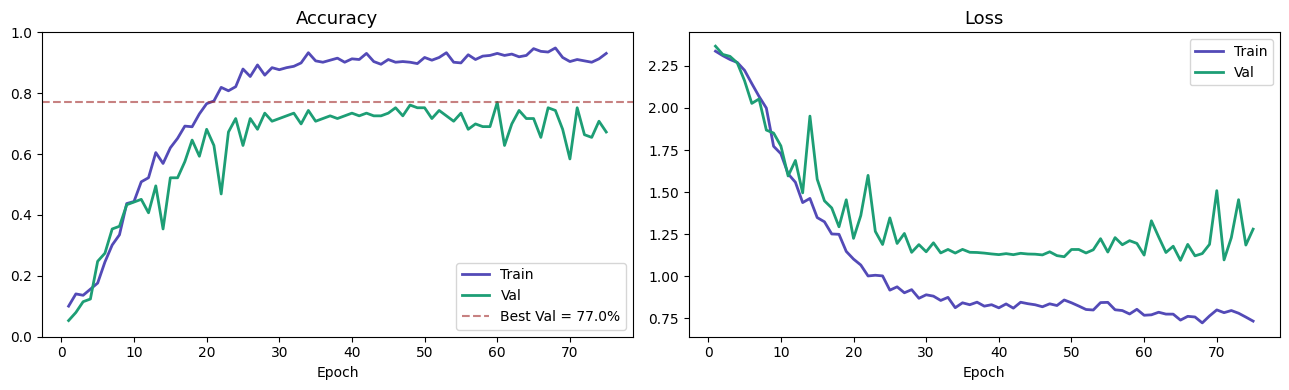

✓ training_curves.png محفوظ

Baseline (random guess) = 10.0%
Best Val Accuracy = 77.0%


In [27]:
# ═══════════════════════════════════════════════════════════════
# 17. Plot Training Curves
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ep = range(1, len(history["tr_acc"]) + 1)

axes[0].plot(ep, history["tr_acc"], label="Train", color="#534AB7", linewidth=2)
axes[0].plot(ep, history["val_acc"], label="Val", color="#1D9E75", linewidth=2)
axes[0].axhline(best_val_acc, color="#A32D2D", linestyle="--", alpha=0.6,
                label=f"Best Val = {best_val_acc:.1%}")
axes[0].set_title("Accuracy", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].plot(ep, history["tr_loss"], label="Train", color="#534AB7", linewidth=2)
axes[1].plot(ep, history["val_loss"], label="Val", color="#1D9E75", linewidth=2)
axes[1].set_title("Loss", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=120, bbox_inches="tight")
plt.show()
print("✓ training_curves.png saved")

print(f"\nBaseline (random guess) = {1/N_CLASSES:.1%}")
print(f"Best Val Accuracy = {best_val_acc:.1%}")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import torch

# ══════════════════════════════════════════════════
# Setup — Short English names for plots
# ══════════════════════════════════════════════════

CLASS_EN = {
    0: "Al-Salam\nAlaykum",
    1: "Ahlan Bikum\nIla Mujaz",
    2: "Afada\nMurasil Al-J.",
    3: "Mujaz Al-Anba'\nMin Qanat",
    4: "Ila\nAl-Liqa'",
    5: "Qala\nMurasil Al-J.",
    6: "Nihayat\nAl-Mujaz",
    7: "Milishia\nAl-Houthi",
    8: "Qalat\nMasadir",
    9: "Min\nJihatih Qal",
}

CLASS_AR = {
    0: "السلام عليكم",
    1: "أهلاً بكم إلى موجز",
    2: "أفاد مراسل الجزيرة",
    3: "موجز الأنباء من قناة",
    4: "إلى اللقاء",
    5: "قال مراسل الجزيرة",
    6: "نهاية الموجز إلى اللقاء",
    7: "ميليشيا الحوثي وقوات",
    8: "قالت مصادر",
    9: "من جهته قال",
}

# Main Colors
C_BLUE   = "#2D4B8E"
C_GREEN  = "#1A7A5E"
C_RED    = "#A32D2D"
C_AMBER  = "#B8720A"
C_LIGHT  = "#F5F7FA"
C_GRID   = "#E2E8F0"

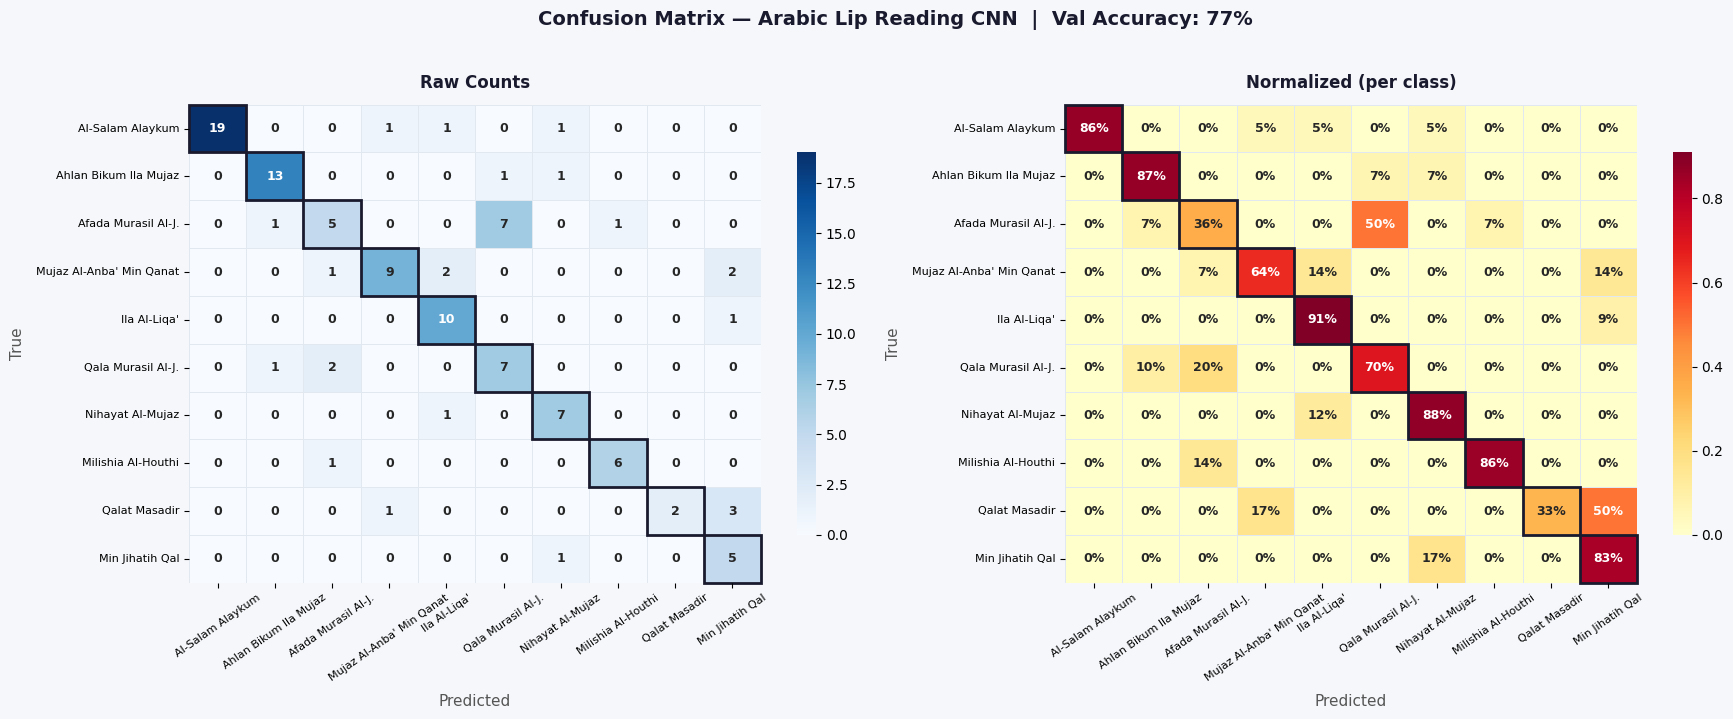

✓ confusion_matrix_pro.png


In [25]:
# ══════════════════════════════════════════════════
# Confusion Matrix
# ══════════════════════════════════════════════════

def plot_confusion_matrix_pro(all_labels, all_preds, save_path="confusion_matrix_pro.png"):
    cm   = confusion_matrix(all_labels, all_preds)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalized

    labels_short = [CLASS_EN[i].replace("\n", " ") for i in range(10)]

    fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor=C_LIGHT)
    fig.suptitle("Confusion Matrix — Arabic Lip Reading CNN  |  Val Accuracy: 77%",
                 fontsize=14, fontweight="bold", color="#1A1A2E", y=1.02)

    for ax, (data, fmt, title, cmap) in zip(axes, [
        (cm,   "d",    "Raw Counts",          "Blues"),
        (cm_n, ".0%",  "Normalized (per class)", "YlOrRd"),
    ]):
        ax.set_facecolor("white")
        g = sns.heatmap(
            data, ax=ax,
            annot=True, fmt=fmt,
            cmap=cmap,
            xticklabels=labels_short,
            yticklabels=labels_short,
            linewidths=0.5, linecolor="#E2E8F0",
            cbar_kws={"shrink": 0.8},
            annot_kws={"size": 9, "weight": "bold"},
        )
        ax.set_title(title, fontsize=12, fontweight="bold",
                     color="#1A1A2E", pad=12)
        ax.set_xlabel("Predicted", fontsize=11, color="#555", labelpad=8)
        ax.set_ylabel("True",      fontsize=11, color="#555", labelpad=8)
        ax.tick_params(axis="x", rotation=35, labelsize=8)
        ax.tick_params(axis="y", rotation=0,  labelsize=8)


        for i in range(10):
            ax.add_patch(plt.Rectangle(
                (i, i), 1, 1,
                fill=False, edgecolor="#1A1A2E",
                linewidth=2, clip_on=False
            ))

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight",
                facecolor=C_LIGHT)
    plt.show()
    print(f"✓ {save_path}")

plot_confusion_matrix_pro(all_labels, all_preds)

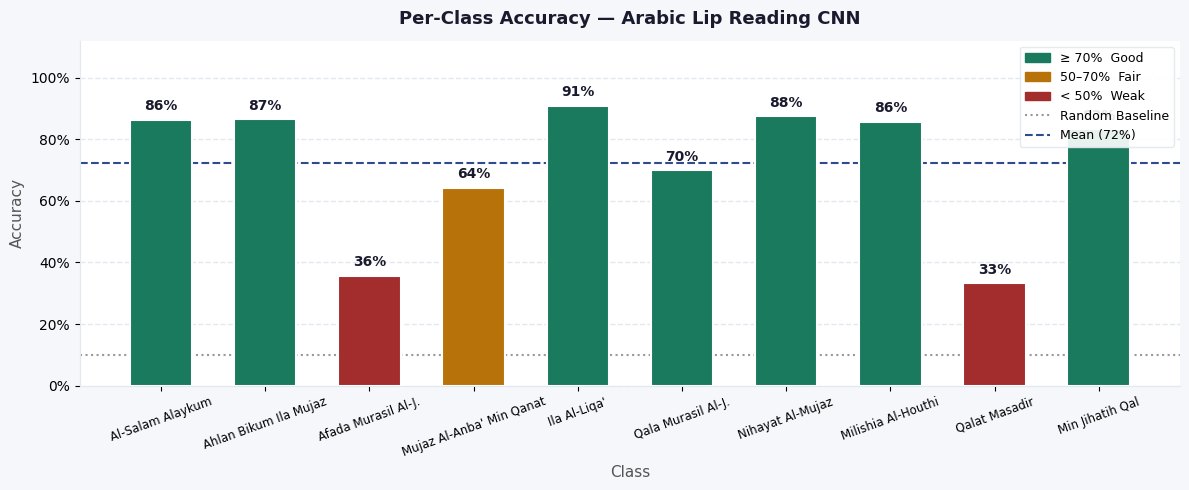

✓ per_class_acc.png


In [26]:
# ══════════════════════════════════════════════════
# 3. Per-Class Accuracy Bar Chart
# ══════════════════════════════════════════════════

def plot_per_class_accuracy(all_labels, all_preds, save_path="per_class_acc.png"):
    cm     = confusion_matrix(all_labels, all_preds)
    per_cls = cm.diagonal() / cm.sum(axis=1)

    fig, ax = plt.subplots(figsize=(12, 5), facecolor=C_LIGHT)
    ax.set_facecolor("white")
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["left","bottom"]].set_color(C_GRID)
    ax.grid(axis="y", color=C_GRID, linewidth=1, linestyle="--", zorder=0)

    colors = [C_GREEN if v >= 0.7 else C_AMBER if v >= 0.5 else C_RED
              for v in per_cls]
    labels = [CLASS_EN[i].replace("\n", " ") for i in range(10)]

    bars = ax.bar(labels, per_cls, color=colors, width=0.6,
                  edgecolor="white", linewidth=1.5, zorder=3)


    for bar, val in zip(bars, per_cls):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.0%}", ha="center", va="bottom",
                fontsize=10, fontweight="bold", color="#1A1A2E")

    ax.axhline(0.1, color="#999", linewidth=1.5, linestyle=":",
               label="Random Baseline (10%)")
    ax.axhline(np.mean(per_cls), color=C_BLUE, linewidth=1.5, linestyle="--",
               label=f"Mean Accuracy ({np.mean(per_cls):.0%})")

    ax.set_ylim(0, 1.12)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.set_title("Per-Class Accuracy — Arabic Lip Reading CNN",
                 fontsize=13, fontweight="bold", color="#1A1A2E", pad=12)
    ax.set_xlabel("Class", fontsize=11, color="#555")
    ax.set_ylabel("Accuracy", fontsize=11, color="#555")
    ax.tick_params(axis="x", rotation=20, labelsize=8.5)

    legend_patches = [
        mpatches.Patch(color=C_GREEN, label="≥ 70%  Good"),
        mpatches.Patch(color=C_AMBER, label="50–70%  Fair"),
        mpatches.Patch(color=C_RED,   label="< 50%  Weak"),
    ]
    ax.legend(handles=legend_patches + [
        plt.Line2D([0],[0], color="#999",  linewidth=1.5, linestyle=":", label="Random Baseline"),
        plt.Line2D([0],[0], color=C_BLUE,  linewidth=1.5, linestyle="--", label=f"Mean ({np.mean(per_cls):.0%})"),
    ], fontsize=9, framealpha=0.9, facecolor="white", edgecolor=C_GRID, loc="upper right")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=C_LIGHT)
    plt.show()
    print(f"✓ {save_path}")

plot_per_class_accuracy(all_labels, all_preds)

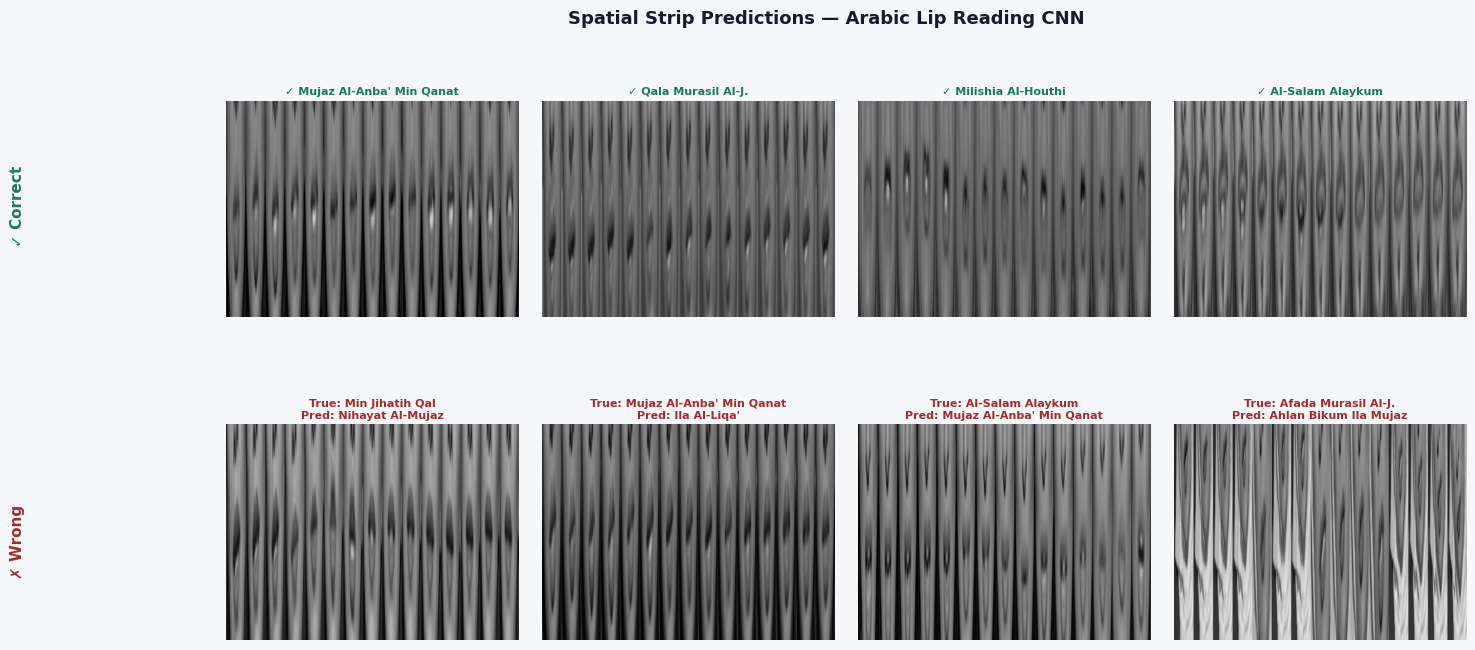

✓ strips_pro.png


In [27]:
# ══════════════════════════════════════════════════
# 4. Spatial Strips
# ══════════════════════════════════════════════════

def plot_strips_pro(X_val, all_labels, all_preds, save_path="strips_pro.png"):
    """عرض صحيح وخاطئ بتصميم نظيف"""
    preds_arr  = np.array(all_preds)
    labels_arr = np.array(all_labels)

    correct_idx = np.where(preds_arr == labels_arr)[0][:4]
    wrong_idx   = np.where(preds_arr != labels_arr)[0][:4]

    fig = plt.figure(figsize=(16, 7), facecolor=C_LIGHT)
    fig.suptitle("Spatial Strip Predictions — Arabic Lip Reading CNN",
                 fontsize=13, fontweight="bold", color="#1A1A2E", y=1.01)

    gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.08)

    for row, (indices, row_label, bg) in enumerate([
        (correct_idx, "✓ Correct", "#F0FFF4"),
        (wrong_idx,   "✗ Wrong",   "#FFF5F5"),
    ]):
        for col, idx in enumerate(indices):
            ax = fig.add_subplot(gs[row, col])
            ax.set_facecolor(bg)

            strip = X_val[idx, 0]
            ax.imshow(strip, cmap="gray", aspect="auto",
                      vmin=0, vmax=1, interpolation="bilinear")

            true_l = CLASS_EN[labels_arr[idx]].replace("\n", " ")
            pred_l = CLASS_EN[preds_arr[idx]].replace("\n", " ")

            if preds_arr[idx] == labels_arr[idx]:
                title = f"✓ {true_l}"
                color = C_GREEN
            else:
                title = f"True: {true_l}\nPred: {pred_l}"
                color = C_RED

            ax.set_title(title, fontsize=8, color=color,
                         fontweight="bold", pad=4)
            ax.axis("off")

            # إطار ملوّن
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor(C_GREEN if preds_arr[idx]==labels_arr[idx] else C_RED)
                spine.set_linewidth(2)

        # عنوان الصف
        fig.text(-0.01, 0.73 - row * 0.48, row_label,
                 fontsize=11, fontweight="bold",
                 color=C_GREEN if row == 0 else C_RED,
                 va="center", rotation=90)

    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=C_LIGHT)
    plt.show()
    print(f"✓ {save_path}")

plot_strips_pro(X_val, all_labels, all_preds)